# Impact of `max_iter` on SimpliPy Simplification

Systematic study of how the maximum number of simplification iterations affects simplification ratio, convergence, and timing.

**Fixed**: `max_pattern_length=7`, `ENGINE='dev_7-3'`, `MODEL='v23.0-3M'`  
**Varied**: `max_iter` ∈ {1, 2, 4, 8, 16, 32, 64, 128}

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import time
import os

from copy import deepcopy
from tqdm import tqdm

from flash_ansr import SkeletonPool, get_path, Tokenizer
from flash_ansr.eval.metrics.bootstrap import bootstrapped_metric_ci
from simplipy import SimpliPyEngine

In [2]:
MODEL = 'v23.0-3M'
ENGINE = 'dev_7-3'
MAX_PATTERN_LENGTH = 7
MAX_ITER_VALUES = [1, 2, 4, 8, 16, 32, 64, 128]

# N_SAMPLES = 2**16
N_SAMPLES = 2**10  # Smaller run for initial exploration
print(f'{N_SAMPLES:,} samples')

1,024 samples


In [3]:
pool = SkeletonPool.from_config(get_path('configs', MODEL, 'skeleton_pool_train.yaml'))
pool.simplify = False
pool.sample_strategy['max_tries'] = 1000

tokenizer = Tokenizer.from_config(get_path('configs', MODEL, 'tokenizer.yaml'))

engine = SimpliPyEngine.load(ENGINE)

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 16618.79it/s]


In [4]:
# Sample expressions once — reused across all max_iter values for paired comparison
sampled_expressions = []
while len(sampled_expressions) < N_SAMPLES:
    skeleton, _, _ = pool.sample_skeleton()
    sampled_expressions.append(skeleton)

print(f'Sampled {len(sampled_expressions)} expressions.')

Sampled 1024 expressions.


## Benchmark

In [5]:
READ = False

In [6]:
results_path = get_path('results', 'simplification', filename='simplification_results_max_iter.pkl')
stats_path = get_path('results', 'simplification', filename='simplification_statistics_by_max_iter.pkl')

if READ and os.path.exists(results_path) and os.path.exists(stats_path):
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    with open(stats_path, 'rb') as f:
        all_stats = pickle.load(f)
    print(f'Loaded results from disk. Keys: {list(results.keys())}')
else:
    results = {}
    all_stats = {}

    for max_iter in MAX_ITER_VALUES:
        key = f'max_iter_{max_iter}'
        results[key] = []
        all_stats[max_iter] = []

        for skeleton in tqdm(sampled_expressions, desc=f'max_iter={max_iter}'):
            start_time = time.time()
            simplified = engine.simplify(
                skeleton,
                max_iter=max_iter,
                max_pattern_length=MAX_PATTERN_LENGTH,
                collect_statistics=True,
            )
            elapsed = time.time() - start_time

            results[key].append({
                'original': skeleton,
                'simplified': simplified,
                'time': elapsed,
            })
            all_stats[max_iter].append(deepcopy(engine.simplification_statistics))

    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
    with open(stats_path, 'wb') as f:
        pickle.dump(all_stats, f)
    print(f'Saved results to {results_path}')

print({k: len(v) for k, v in results.items()})

max_iter=128: 100%|██████████| 1024/1024 [03:15<00:00,  5.24it/s]


Saved results to /home/psaegert/Projects/flash-ansr/results/simplification/simplification_results_max_iter.pkl
{'max_iter_1': 1024, 'max_iter_2': 1024, 'max_iter_4': 1024, 'max_iter_8': 1024, 'max_iter_16': 1024, 'max_iter_32': 1024, 'max_iter_64': 1024, 'max_iter_128': 1024}


## Core Analysis

In [7]:
# Color palette — sequential blues for increasing max_iter
all_colors = {
    'max_iter_1': '#ade8f4',
    'max_iter_2': '#90e0ef',
    'max_iter_4': '#48cae4',
    'max_iter_8': '#00b4d8',
    'max_iter_16': '#0096c7',
    'max_iter_32': '#0077b6',
    'max_iter_64': '#023e8a',
    'max_iter_128': '#03045e',
}

legend_labels = {f'max_iter_{mi}': f'max_iter = {mi}' for mi in MAX_ITER_VALUES}

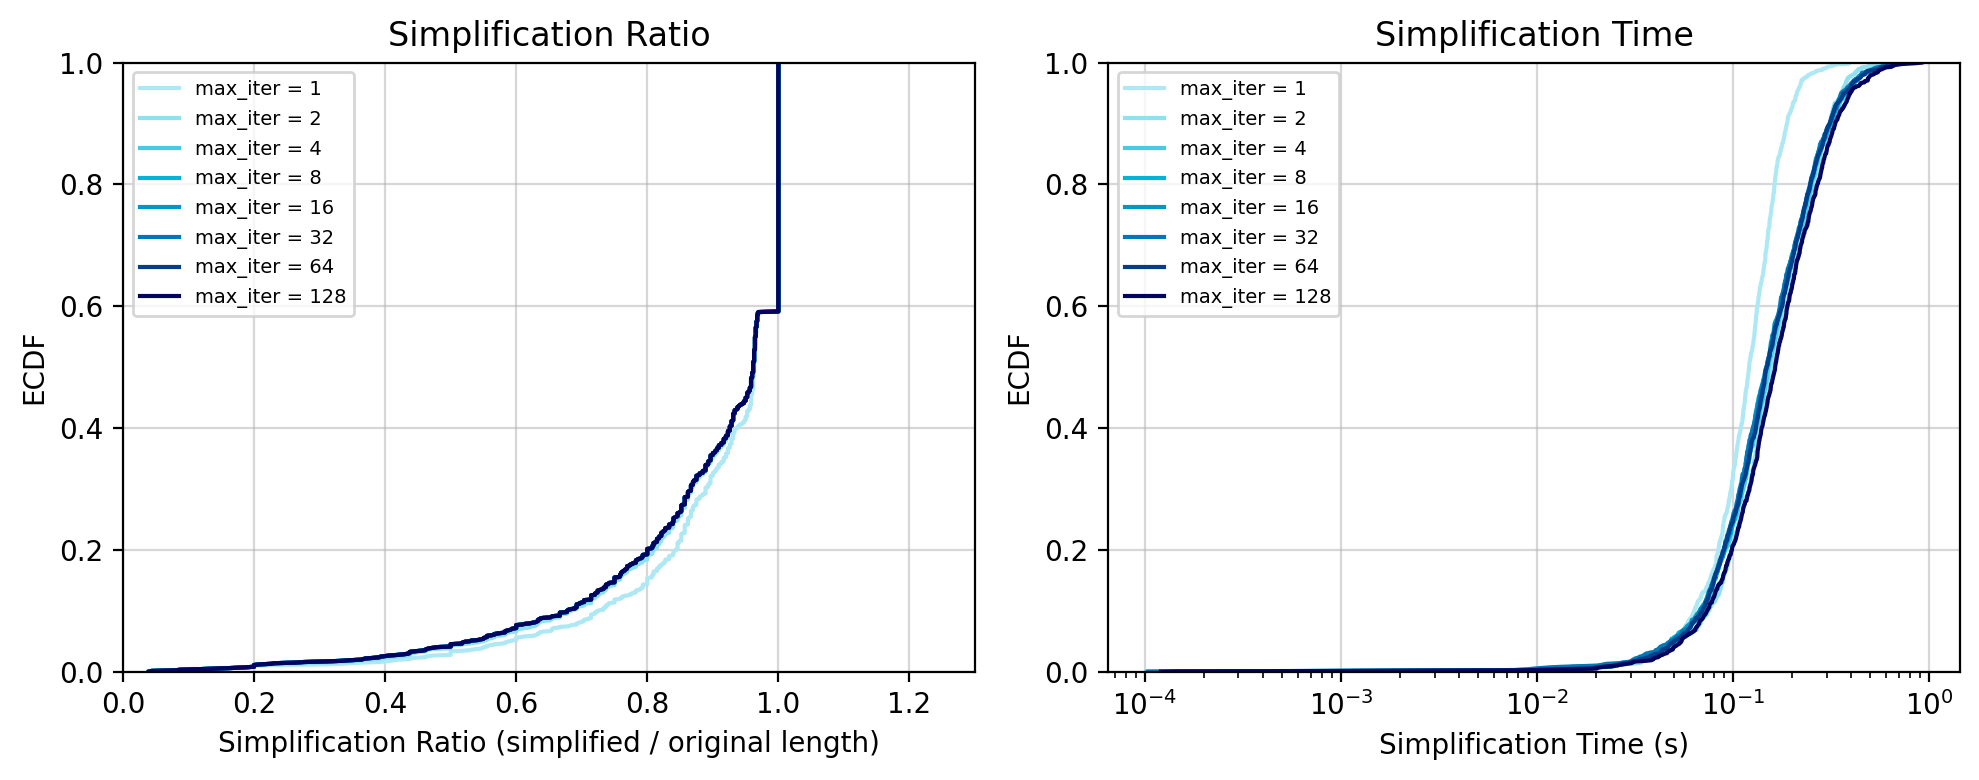

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

# --- Left: ECDF of simplification ratio ---
for key in results:
    method_results = results[key]
    original_lengths = np.array([len(r['original']) for r in method_results])
    simplified_lengths = np.array([
        len(r['simplified']) if r['simplified'] is not None else len(r['original'])
        for r in method_results
    ])
    ratios = simplified_lengths / np.maximum(original_lengths, 1)

    x = np.sort(ratios)
    y = np.linspace(0, 1, len(ratios))

    axes[0].plot(x, y, label=legend_labels[key], color=all_colors[key])

axes[0].set_xlabel('Simplification Ratio (simplified / original length)')
axes[0].set_ylabel('ECDF')
axes[0].set_xlim(0, 1.3)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.5)
axes[0].set_title('Simplification Ratio')

# --- Right: ECDF of simplification time ---
for key in results:
    method_results = results[key]
    times = np.array([r['time'] for r in method_results])

    x = np.sort(times)
    y = np.linspace(0, 1, len(times))

    axes[1].plot(x, y, label=legend_labels[key], color=all_colors[key])

axes[1].set_xscale('log')
axes[1].set_xlabel('Simplification Time (s)')
axes[1].set_ylabel('ECDF')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.5)
axes[1].set_title('Simplification Time')

fig.tight_layout()
plt.savefig(get_path('results', 'simplification', filename='max_iter_ecdf.svg'))
plt.show()

In [9]:
# Summary statistics table
summary_rows = []
for mi in MAX_ITER_VALUES:
    key = f'max_iter_{mi}'
    method_results = results[key]
    stats_list = all_stats[mi]
    n = len(method_results)

    original_lengths = np.array([len(r['original']) for r in method_results])
    simplified_lengths = np.array([
        len(r['simplified']) if r['simplified'] is not None else len(r['original'])
        for r in method_results
    ])
    ratios = simplified_lengths / np.maximum(original_lengths, 1)
    times = np.array([r['time'] for r in method_results])

    converged_count = sum(1 for s in stats_list if s.converged)
    rejected_count = sum(1 for s in stats_list if s.result_rejected)
    iters_used = np.array([s.iterations_used for s in stats_list])

    summary_rows.append({
        'max_iter': mi,
        'N': n,
        'ratio (mean)': np.mean(ratios),
        'ratio (median)': np.median(ratios),
        'converged (%)': 100 * converged_count / n,
        'rejected (%)': 100 * rejected_count / n,
        'iterations (mean)': np.mean(iters_used),
        'iterations (median)': np.median(iters_used),
        'time (mean, ms)': np.mean(times) * 1000,
        'time (median, ms)': np.median(times) * 1000,
    })

summary_df = pd.DataFrame(summary_rows).set_index('max_iter')
summary_df

,N,ratio (mean),ratio (median),converged (%),rejected (%),iterations (mean),iterations (median),"time (mean, ms)","time (median, ms)"
max_iter,,,,,,,,,
1,1024,0.903627,0.962963,40.917969,0.0,1.000000,1.0,125.207078,120.501995
2,1024,0.890077,0.961538,86.132812,0.0,1.590820,2.0,178.492726,157.780766
4,1024,0.887442,0.961538,99.609375,0.0,1.758789,2.0,176.492139,151.224971
8,1024,0.887329,0.961538,100.000000,0.0,1.765625,2.0,174.504899,148.218870
16,1024,0.887329,0.961538,100.000000,0.0,1.765625,2.0,172.872170,147.953272
32,1024,0.887329,0.961538,100.000000,0.0,1.765625,2.0,172.395342,147.608399
64,1024,0.887329,0.961538,100.000000,0.0,1.765625,2.0,174.488577,148.259521
128,1024,0.887329,0.961538,100.000000,0.0,1.765625,2.0,189.305339,163.662076


## Diagnostics

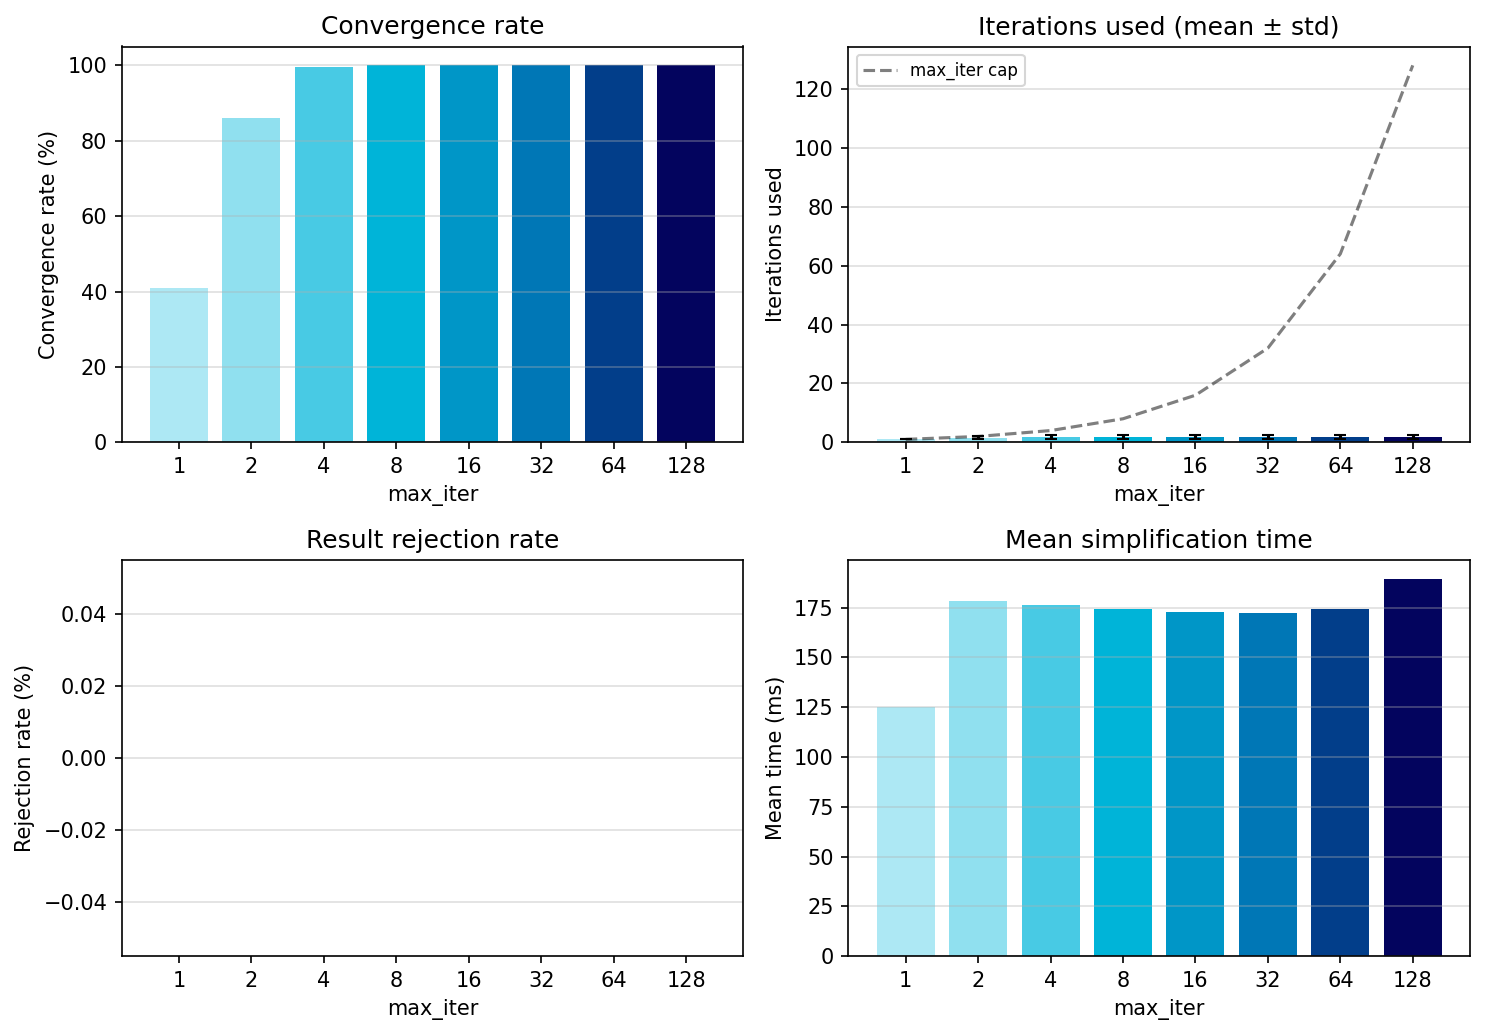

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=150)
axes = axes.flatten()

colors = [all_colors[f'max_iter_{mi}'] for mi in MAX_ITER_VALUES]

# --- 1. Convergence rate ---
conv_rates = [summary_df.loc[mi, 'converged (%)'] for mi in MAX_ITER_VALUES]
axes[0].bar(range(len(MAX_ITER_VALUES)), conv_rates, color=colors)
axes[0].set_xticks(range(len(MAX_ITER_VALUES)))
axes[0].set_xticklabels(MAX_ITER_VALUES)
axes[0].set_xlabel('max_iter')
axes[0].set_ylabel('Convergence rate (%)')
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_title('Convergence rate')

# --- 2. Iterations used (mean ± std) ---
iter_means = []
iter_stds = []
for mi in MAX_ITER_VALUES:
    iters = [s.iterations_used for s in all_stats[mi]]
    iter_means.append(np.mean(iters))
    iter_stds.append(np.std(iters))

x = np.arange(len(MAX_ITER_VALUES))
axes[1].bar(x, iter_means, color=colors)
axes[1].errorbar(x, iter_means, yerr=iter_stds, fmt='none', ecolor='black', capsize=3)
axes[1].plot(x, MAX_ITER_VALUES, 'k--', alpha=0.5, label='max_iter cap')
axes[1].set_xticks(x)
axes[1].set_xticklabels(MAX_ITER_VALUES)
axes[1].set_xlabel('max_iter')
axes[1].set_ylabel('Iterations used')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.4)
axes[1].set_title('Iterations used (mean ± std)')

# --- 3. Rejection rate ---
rej_rates = [summary_df.loc[mi, 'rejected (%)'] for mi in MAX_ITER_VALUES]
axes[2].bar(range(len(MAX_ITER_VALUES)), rej_rates, color=colors)
axes[2].set_xticks(range(len(MAX_ITER_VALUES)))
axes[2].set_xticklabels(MAX_ITER_VALUES)
axes[2].set_xlabel('max_iter')
axes[2].set_ylabel('Rejection rate (%)')
axes[2].grid(axis='y', alpha=0.4)
axes[2].set_title('Result rejection rate')

# --- 4. Mean time ---
mean_times = [summary_df.loc[mi, 'time (mean, ms)'] for mi in MAX_ITER_VALUES]
axes[3].bar(range(len(MAX_ITER_VALUES)), mean_times, color=colors)
axes[3].set_xticks(range(len(MAX_ITER_VALUES)))
axes[3].set_xticklabels(MAX_ITER_VALUES)
axes[3].set_xlabel('max_iter')
axes[3].set_ylabel('Mean time (ms)')
axes[3].grid(axis='y', alpha=0.4)
axes[3].set_title('Mean simplification time')

fig.tight_layout()
plt.savefig(get_path('results', 'simplification', filename='max_iter_diagnostics.svg'))
plt.show()

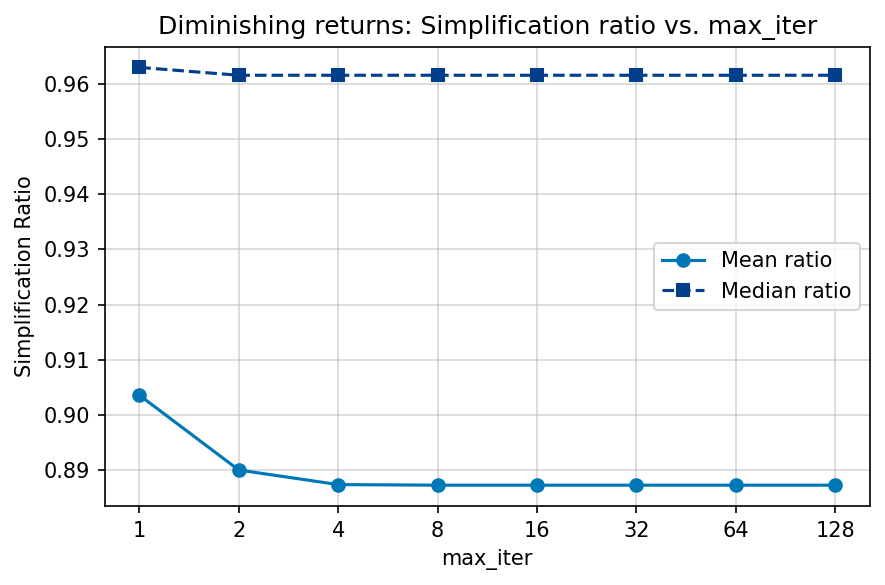

In [11]:
# Diminishing returns: mean simplification ratio vs max_iter
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

mean_ratios = [summary_df.loc[mi, 'ratio (mean)'] for mi in MAX_ITER_VALUES]
median_ratios = [summary_df.loc[mi, 'ratio (median)'] for mi in MAX_ITER_VALUES]

ax.plot(MAX_ITER_VALUES, mean_ratios, 'o-', color='#0077b6', label='Mean ratio')
ax.plot(MAX_ITER_VALUES, median_ratios, 's--', color='#023e8a', label='Median ratio')
ax.set_xscale('log', base=2)
ax.set_xticks(MAX_ITER_VALUES)
ax.set_xticklabels(MAX_ITER_VALUES)
ax.set_xlabel('max_iter')
ax.set_ylabel('Simplification Ratio')
ax.legend()
ax.grid(alpha=0.5)
ax.set_title('Diminishing returns: Simplification ratio vs. max_iter')

fig.tight_layout()
plt.savefig(get_path('results', 'simplification', filename='max_iter_diminishing_returns.svg'))
plt.show()

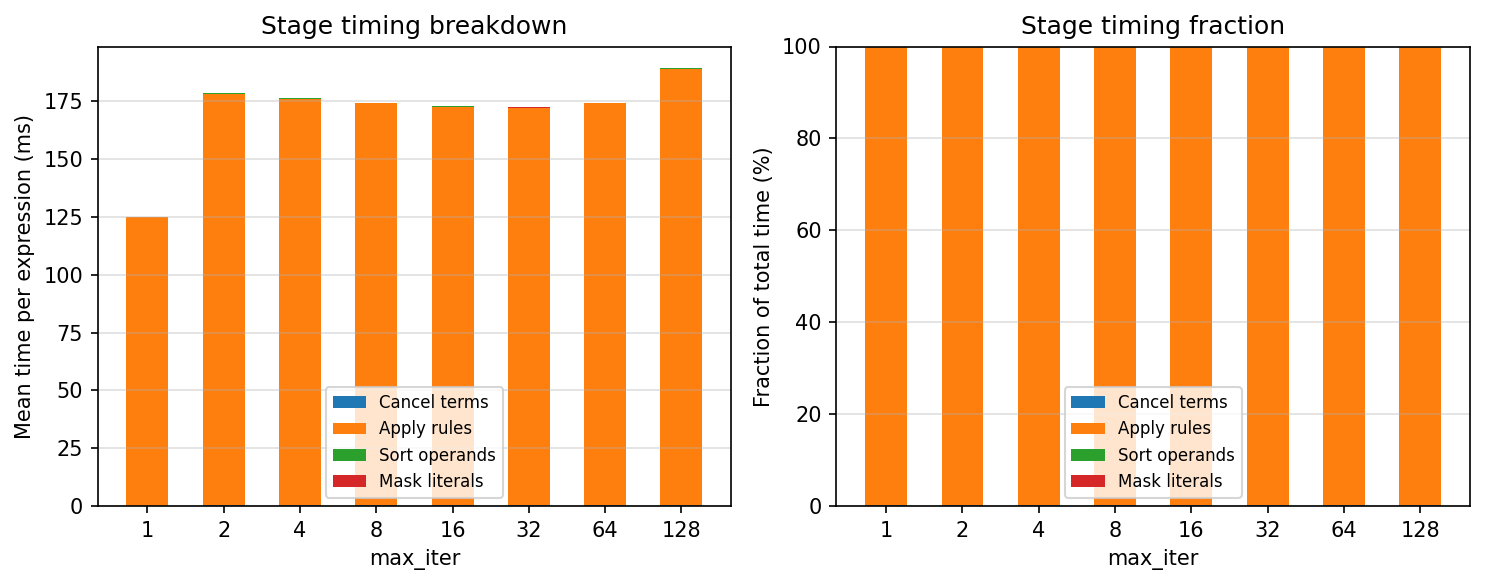

In [12]:
# Stage timing breakdown per max_iter
stage_names = ['cancel_terms', 'apply_rules', 'sort_operands', 'mask_literals']
stage_labels = ['Cancel terms', 'Apply rules', 'Sort operands', 'Mask literals']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# --- Absolute timing ---
stage_means = {stage: [] for stage in stage_names}
for mi in MAX_ITER_VALUES:
    for stage in stage_names:
        stage_means[stage].append(np.mean([s.stage_timings[stage] for s in all_stats[mi]]))

x = np.arange(len(MAX_ITER_VALUES))
w = 0.55
bottom = np.zeros(len(MAX_ITER_VALUES))
for stage, label in zip(stage_names, stage_labels):
    vals = np.array(stage_means[stage])
    axes[0].bar(x, vals * 1000, w, bottom=bottom * 1000, label=label)
    bottom += vals

axes[0].set_xlabel('max_iter')
axes[0].set_ylabel('Mean time per expression (ms)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(MAX_ITER_VALUES)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_title('Stage timing breakdown')

# --- Fraction ---
stage_fractions = {stage: [] for stage in stage_names}
for idx, mi in enumerate(MAX_ITER_VALUES):
    total = sum(stage_means[stage][idx] for stage in stage_names)
    for stage in stage_names:
        stage_fractions[stage].append(stage_means[stage][idx] / max(total, 1e-12))

bottom = np.zeros(len(MAX_ITER_VALUES))
for stage, label in zip(stage_names, stage_labels):
    vals = np.array(stage_fractions[stage])
    axes[1].bar(x, vals * 100, w, bottom=bottom * 100, label=label)
    bottom += vals

axes[1].set_xlabel('max_iter')
axes[1].set_ylabel('Fraction of total time (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(MAX_ITER_VALUES)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.4)
axes[1].set_title('Stage timing fraction')

fig.tight_layout()
plt.savefig(get_path('results', 'simplification', filename='max_iter_stage_timings.svg'))
plt.show()

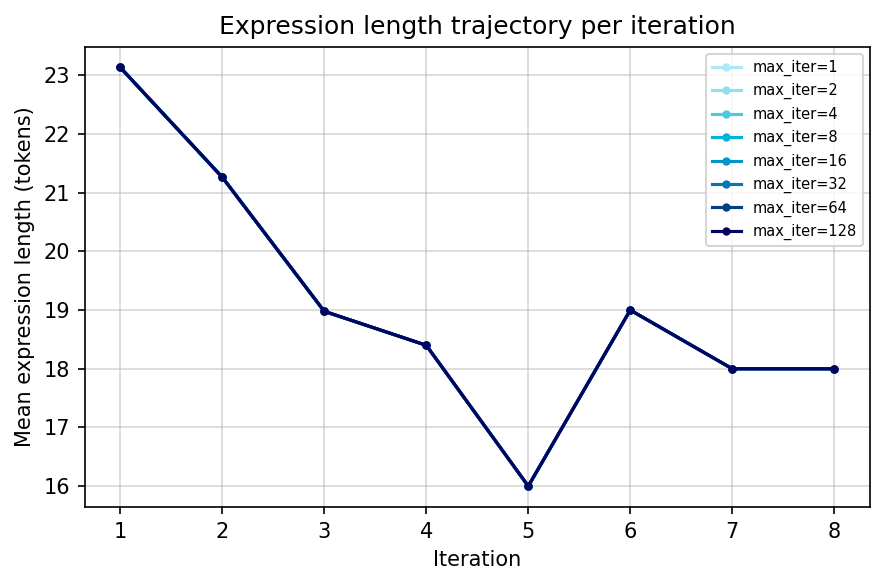

In [13]:
# Per-iteration length trajectory: how quickly does the expression shrink?
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

for mi in MAX_ITER_VALUES:
    # Collect per-iteration lengths; pad with NaN for expressions that converged early
    max_iters_observed = max(len(s.per_iteration_lengths) for s in all_stats[mi])

    # Build a 2D array: (n_samples, max_iters_observed) with NaN padding
    length_matrix = np.full((len(all_stats[mi]), max_iters_observed), np.nan)
    for i, s in enumerate(all_stats[mi]):
        for j, entry in enumerate(s.per_iteration_lengths):
            length_matrix[i, j] = entry.get('after_rules', entry.get('after_cancel', np.nan))

    # Compute mean length at each iteration (ignoring NaN)
    mean_lengths = np.nanmean(length_matrix, axis=0)
    iterations = np.arange(1, len(mean_lengths) + 1)

    ax.plot(iterations, mean_lengths, 'o-', color=all_colors[f'max_iter_{mi}'],
            label=f'max_iter={mi}', markersize=3)

ax.set_xlabel('Iteration')
ax.set_ylabel('Mean expression length (tokens)')
ax.legend(fontsize=7)
ax.grid(alpha=0.5)
ax.set_title('Expression length trajectory per iteration')

fig.tight_layout()
plt.savefig(get_path('results', 'simplification', filename='max_iter_length_trajectory.svg'))
plt.show()

## Bootstrapped Confidence Intervals

In [14]:
# Bootstrapped CIs on simplification ratio
print('Simplification ratio (bootstrapped CIs):')
print(f'{"max_iter":>10} {"median":>10} {"lower":>10} {"upper":>10}')
for mi in MAX_ITER_VALUES:
    key = f'max_iter_{mi}'
    method_results = results[key]
    original_lengths = np.array([len(r['original']) for r in method_results])
    simplified_lengths = np.array([
        len(r['simplified']) if r['simplified'] is not None else len(r['original'])
        for r in method_results
    ])
    ratios = simplified_lengths / np.maximum(original_lengths, 1)

    median, lower, upper = bootstrapped_metric_ci(ratios, np.mean)
    print(f'{mi:>10} {median:>10.4f} {lower:>10.4f} {upper:>10.4f}')

Simplification ratio (bootstrapped CIs):
  max_iter     median      lower      upper
         1     0.9036     0.8943     0.9125
         2     0.8901     0.8800     0.8999
         4     0.8875     0.8772     0.8976
         8     0.8873     0.8766     0.8973
        16     0.8875     0.8771     0.8974
        32     0.8874     0.8767     0.8975
        64     0.8873     0.8768     0.8975
       128     0.8874     0.8768     0.8974


In [15]:
# Bootstrapped CIs on rejection rate
print('Rejection rate (bootstrapped CIs):')
print(f'{"max_iter":>10} {"median":>10} {"lower":>10} {"upper":>10}')
for mi in MAX_ITER_VALUES:
    rejected = np.array([s.result_rejected for s in all_stats[mi]], dtype=float)
    median, lower, upper = bootstrapped_metric_ci(rejected, np.mean)
    print(f'{mi:>10} {median*100:>9.2f}% {lower*100:>9.2f}% {upper*100:>9.2f}%')

Rejection rate (bootstrapped CIs):
  max_iter     median      lower      upper
         1      0.00%      0.00%      0.00%
         2      0.00%      0.00%      0.00%
         4      0.00%      0.00%      0.00%
         8      0.00%      0.00%      0.00%
        16      0.00%      0.00%      0.00%
        32      0.00%      0.00%      0.00%
        64      0.00%      0.00%      0.00%
       128      0.00%      0.00%      0.00%


In [16]:
# Bootstrapped CIs on convergence rate
print('Convergence rate (bootstrapped CIs):')
print(f'{"max_iter":>10} {"median":>10} {"lower":>10} {"upper":>10}')
for mi in MAX_ITER_VALUES:
    converged = np.array([s.converged for s in all_stats[mi]], dtype=float)
    median, lower, upper = bootstrapped_metric_ci(converged, np.mean)
    print(f'{mi:>10} {median*100:>9.2f}% {lower*100:>9.2f}% {upper*100:>9.2f}%')

Convergence rate (bootstrapped CIs):
  max_iter     median      lower      upper
         1     40.92%     37.89%     43.95%
         2     86.13%     83.98%     88.28%
         4     99.61%     99.22%     99.90%
         8    100.00%    100.00%    100.00%
        16    100.00%    100.00%    100.00%
        32    100.00%    100.00%    100.00%
        64    100.00%    100.00%    100.00%
       128    100.00%    100.00%    100.00%
